# Car Rental Damage Audit System (Before vs After)

## Imports

In [1]:
import os, json, re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

%matplotlib inline

## 1. Setup Paths and Load YOLO Damage Model

In [2]:
PROJECT_ROOT = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO"
BEST_WEIGHTS = os.path.join(PROJECT_ROOT, "models", "runs", "car_damage_yolov8s", "weights", "best.pt")

DB_PATH = os.path.join(PROJECT_ROOT, "outputs", "rental_damage_db.json")
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)

damage_model = YOLO(BEST_WEIGHTS)

print("Loaded YOLO weights:", BEST_WEIGHTS)
print("DB path:", DB_PATH)

Loaded YOLO weights: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt
DB path: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\outputs\rental_damage_db.json


## 2. OCR Setup (EasyOCR)

In [3]:
import easyocr
ocr_reader = easyocr.Reader(['en'], gpu=True)

def clean_plate_text(s: str) -> str:
    s = s.upper()
    s = re.sub(r'[^A-Z0-9]', '', s)
    return s

## 3. License Plate Candidate Detection (Classical CV)

In [4]:
def plate_likeness_score(gray, x, y, w, h):
    """
    Score a candidate region as "plate-like" using classical cues:
    - Bright background (plates often bright)
    - Strong vertical edges (characters)
    - Reasonable aspect ratio
    """
    patch = gray[y:y+h, x:x+w]
    if patch.size == 0:
        return -1.0

    brightness = float(np.mean(patch))  # higher is better

    sobelx = cv2.Sobel(patch, cv2.CV_32F, 1, 0, ksize=3)
    edge_strength = float(np.mean(np.abs(sobelx)))  # higher is better

    aspect = w / (h + 1e-6)
    aspect_score = 1.0 if 2.0 <= aspect <= 6.5 else 0.4

    return 0.4 * brightness + 0.4 * edge_strength + 0.2 * aspect_score


def get_plate_candidates(image_bgr, debug=False):
    """
    Full-image, lecture-aligned plate candidate generation:
    grayscale -> bilateral -> multi-scale blackhat -> sobelX -> threshold -> closing/opening
    -> contours -> geometric filtering -> plate-likeness scoring -> sorted candidates.

    Returns a list of tuples: (x, y, w, h, score)
    Sorted best-first.
    """
    img = image_bgr.copy()
    H, W = img.shape[:2]

    # 1) Preprocess
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 11, 17, 17)

    # 2) Multi-scale blackhat (handles different plate sizes/distances)
    kernels = [
        cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3)),
        cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5)),
        cv2.getStructuringElement(cv2.MORPH_RECT, (17, 7))
    ]
    blackhats = [cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, k) for k in kernels]
    blackhat = np.max(np.stack(blackhats, axis=0), axis=0).astype(np.uint8)

    # 3) Vertical edge emphasis (characters)
    gradX = cv2.Sobel(blackhat, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=3)
    gradX = np.absolute(gradX)
    gradX = (255 * (gradX / (gradX.max() + 1e-9))).astype("uint8")

    # 4) Threshold
    gradX = cv2.GaussianBlur(gradX, (5, 5), 0)
    _, thresh = cv2.threshold(gradX, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 5) Morphology to connect characters into a plate-like blob
    closeK = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 3))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, closeK, iterations=2)

    openK = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(closed, cv2.MORPH_OPEN, openK, iterations=1)

    # 6) Contours
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    img_area = float(W * H)

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = float(w * h)
        aspect = w / float(h + 1e-9)
        area_ratio = area / (img_area + 1e-9)

        # Geometric filtering (broad but sensible)
        if w < 60 or h < 20:
            continue
        if not (2.0 <= aspect <= 7.0):
            continue
        if not (0.0005 <= area_ratio <= 0.25):
            continue

        score = plate_likeness_score(gray, x, y, w, h)
        candidates.append((x, y, w, h, score))

    # 7) Sort best-first by score (NOT by area)
    candidates.sort(key=lambda t: t[4], reverse=True)

    # 8) Debug visualization
    if debug:
        vis = img.copy()
        for (x, y, w, h, s) in candidates[:10]:
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(vis, f"{s:.1f}", (x, max(0, y - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title("Top Plate Candidates (Scored)")
        plt.axis("off")
        plt.show()

    return candidates

## 4. License Plate Text Validation

In [5]:
def is_valid_plate_text(text):
    """
    Validate whether OCR output is a plausible license plate string.

    Accepted examples:
    - CAV
    - CAV1393
    - WPCA1393
    - 1393
    """

    if text is None:
        return False

    text = text.strip().upper()

    # Minimum length
    if len(text) < 3:
        return False

    # Character type checks
    has_alpha = any(c.isalpha() for c in text)
    has_digit = any(c.isdigit() for c in text)

    # Must contain both letters and digits OR be a valid numeric-only plate
    if not (has_alpha and has_digit):
        return False

    # Reject very short junk like "U7"
    if len(text) < 4:
        return False

    return True

## 5. OCR Plate (Try multiple candidates, return best text)

In [6]:
def ocr_plate_best(image_bgr, debug=False, max_candidates=8):
    boxes = get_plate_candidates(image_bgr, debug=debug)

    best_text, best_score, best_bbox = None, 0.0, None

    for (x, y, w, h, _) in boxes[:max_candidates]:
        pad = int(0.10 * w)
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(image_bgr.shape[1], x + w + pad)
        y2 = min(image_bgr.shape[0], y + h + pad)

        roi = image_bgr[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        # Improve OCR
        roi = cv2.resize(roi, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
        roi = cv2.bilateralFilter(roi, 9, 75, 75)
        rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

        results = ocr_reader.readtext(rgb, detail=1)
        if not results:
            continue

        tokens = []
        confs = []

        for (_, txt, cf) in results:
            cleaned = clean_plate_text(txt)
            if cleaned:
                tokens.append(cleaned)
                confs.append(float(cf))

        if not tokens:
            continue

        merged_text = "".join(tokens)
        avg_conf = float(np.mean(confs))

        if debug:
            plt.figure(figsize=(6, 2))
            plt.imshow(rgb)
            plt.title(f"OCR: {merged_text} (avg_conf={avg_conf:.2f})")
            plt.axis("off")
            plt.show()

        if not is_valid_plate_text(merged_text):
            continue

        # Final score: confidence + small bonus for longer strings
        score = avg_conf + 0.05 * len(merged_text)

        if score > best_score:
            best_text = merged_text
            best_score = score
            best_bbox = [int(x1), int(y1), int(x2), int(y2)]

    # Final clean + return
    if best_text is not None:
        best_text = clean_plate_text(best_text)

    return best_text, best_score, best_bbox

## 6. Damage Detection (YOLOv8)

In [7]:
def detect_damages(image_bgr, conf=0.25):
    results = damage_model(image_bgr, verbose=False)[0]
    dets = []

    if results.boxes is None:
        return dets

    for b in results.boxes:
        cls_id = int(b.cls.item())
        cls_name = damage_model.names[cls_id]
        score = float(b.conf.item())
        if score < conf:
            continue

        x1, y1, x2, y2 = map(float, b.xyxy[0].tolist())
        dets.append({
            "class": cls_name,
            "conf": score,
            "bbox": [x1, y1, x2, y2]
        })

    return dets

In [19]:
# Reset DB (run once before a fresh demo)
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)
print("DB reset done:", DB_PATH)

DB reset done: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\outputs\rental_damage_db.json


## 7. Core Audit Logic (DB + IoU + BEFORE Register + AFTER Compare)

In [20]:
def load_db(db_path=DB_PATH):
    if os.path.exists(db_path):
        with open(db_path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_db(db, db_path=DB_PATH):
    os.makedirs(os.path.dirname(db_path), exist_ok=True)
    with open(db_path, "w", encoding="utf-8") as f:
        json.dump(db, f, indent=2)

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw * ih
    areaA = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    areaB = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def find_new_damages(before, after, iou_thr=0.5):
    used_before = set()
    new_after = []

    for a in after:
        best_j, best_iou = None, 0.0
        for j, b in enumerate(before):
            if j in used_before:
                continue
            if b["class"] != a["class"]:
                continue
            v = iou_xyxy(b["bbox"], a["bbox"])
            if v > best_iou:
                best_iou, best_j = v, j

        if best_j is not None and best_iou >= iou_thr:
            used_before.add(best_j)
        else:
            new_after.append(a)

    return new_after

def register_before(before_img_path, damage_conf=0.25, plate_min_conf=0.35, debug_plate=False):
    img = cv2.imread(before_img_path)
    if img is None:
        raise FileNotFoundError(before_img_path)

    plate, pconf, pbbox = ocr_plate_best(img, debug=debug_plate)
    if plate is None or pconf < plate_min_conf:
        return {"error": "Plate OCR failed. Use clearer plate image."}

    damages = detect_damages(img, conf=damage_conf)

    db = load_db()
    db[plate] = {
        "plate_conf": pconf,
        "plate_bbox": pbbox,
        "before_image": before_img_path,
        "before_damages": damages
    }
    save_db(db)

    return {"plate": plate, "plate_conf": pconf, "saved_before_count": len(damages)}

def get_new_damages(after_img_path, damage_conf=0.25, plate_min_conf=0.35, iou_thr=0.5, debug_plate=False):
    img = cv2.imread(after_img_path)
    if img is None:
        raise FileNotFoundError(after_img_path)

    plate, pconf, pbbox = ocr_plate_best(img, debug=debug_plate)

    db = load_db()

    # Case 0: DB empty
    if len(db) == 0:
        return {"error": "Database is empty. Register BEFORE image first."}

    # OCR succeeded and plate exists in DB
    if plate is not None and is_valid_plate_text(plate) and pconf >= plate_min_conf and plate in db:
        matched_plate = plate

    # OCR failed → fallback to single BEFORE record
    elif len(db) == 1:
        matched_plate = list(db.keys())[0]

    # OCR failed and multiple vehicles exist
    else:
        return {"error": "Plate OCR failed and multiple vehicles exist. Manual verification required."}

    before_damages = db[matched_plate]["before_damages"]
    after_damages = detect_damages(img, conf=damage_conf)
    new_damages = find_new_damages(before_damages, after_damages, iou_thr=iou_thr)

    # Save check result (optional)
    db[matched_plate]["last_after_image"] = after_img_path
    db[matched_plate]["last_after_damages"] = after_damages
    db[matched_plate]["new_damages_last_check"] = new_damages
    save_db(db)

    return {
        "vehicle_id": matched_plate,
        "new_damages": new_damages
    }

## 8. Register BEFORE Image

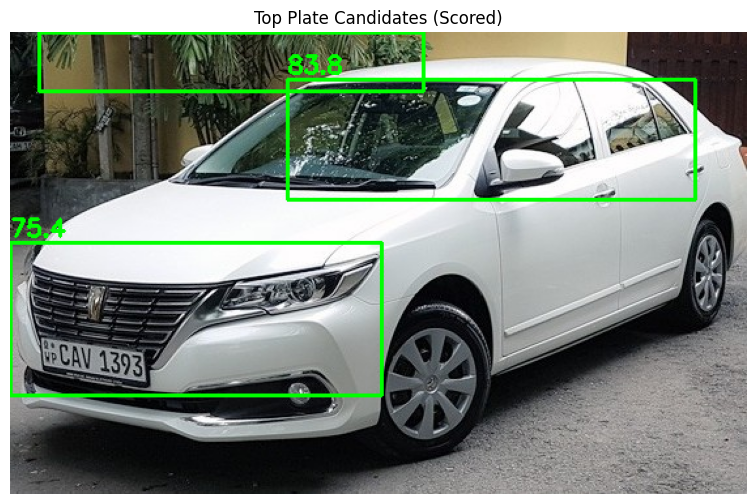

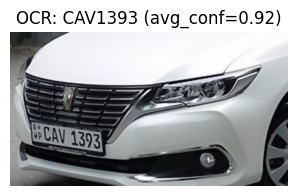

{'plate': 'CAV1393', 'plate_conf': 1.2736309577461535, 'saved_before_count': 1}

In [22]:
before_img = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\assets\before.jpg"
out_before = register_before(before_img, damage_conf=0.35, plate_min_conf=0.35, debug_plate=True)
out_before

## 9. Compare AFTER Image (Final Output: New Damages List)

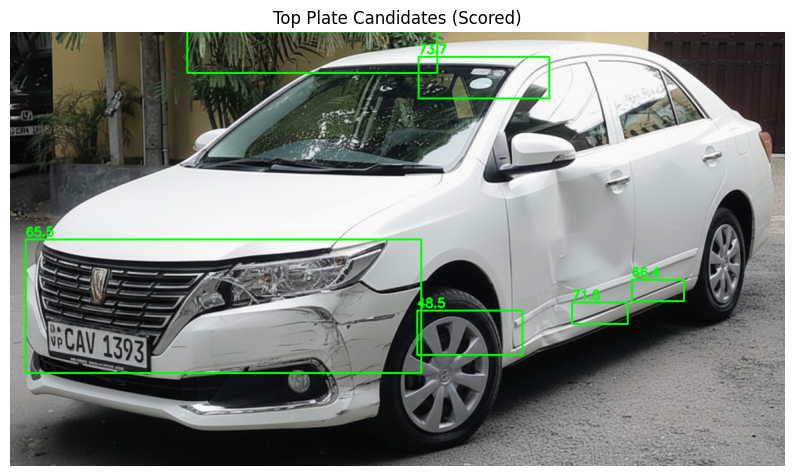

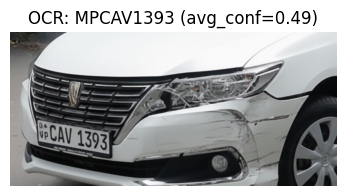

{'vehicle_id': 'CAV1393',
 'new_damages': [{'class': 'dent',
   'conf': 0.6633700132369995,
   'bbox': [788.104736328125,
    207.6453857421875,
    930.9102172851562,
    394.2262268066406]},
  {'class': 'scratch',
   'conf': 0.5341464877128601,
   'bbox': [477.5918273925781,
    384.2474060058594,
    579.3243408203125,
    566.6740112304688]},
  {'class': 'lamp broken',
   'conf': 0.43188920617103577,
   'bbox': [271.7450866699219,
    329.3757629394531,
    525.7465209960938,
    414.42132568359375]},
  {'class': 'scratch',
   'conf': 0.4061202108860016,
   'bbox': [254.04331970214844,
    407.2244873046875,
    494.08978271484375,
    511.48944091796875]},
  {'class': 'scratch',
   'conf': 0.39760443568229675,
   'bbox': [371.58660888671875,
    405.5040588378906,
    496.1075439453125,
    509.8425598144531]}]}

In [35]:
after_img = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\assets\after.png"
new_list = get_new_damages(after_img, damage_conf=0.35, plate_min_conf=0.35, iou_thr=0.5, debug_plate=True)
new_list

## 10. Damage Visualization and Comparison (Before vs After)

In [24]:
# Consistent colors per damage class
DAMAGE_COLORS = {
    "dent": (255, 0, 0),          # Blue
    "scratch": (0, 255, 255),     # Yellow
    "crack": (0, 0, 255),         # Red
    "glass shatter": (255, 255, 0), # Cyan
    "lamp broken": (255, 0, 255), # Magenta
    "tire flat": (0, 165, 255)    # Orange
}

In [25]:
def visualize_damages(image_path, damages, title="Damage Detection"):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(image_path)

    vis = img.copy()

    for d in damages:
        x1, y1, x2, y2 = map(int, d["bbox"])
        cls = d["class"]
        conf = d["conf"]

        color = DAMAGE_COLORS.get(cls, (0, 255, 0))  # fallback green
        label = f"{cls} ({conf:.2f})"

        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            vis,
            label,
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [26]:
def print_damage_list(damages, header="Damage List"):
    print(f"\n{header}")
    print("-" * len(header))

    if not damages:
        print("No damages detected.")
        return

    for i, d in enumerate(damages, 1):
        print(f"{i}. {d['class']}  | confidence = {d['conf']:.2f}")

## 11. Pre-existing Damage Detection

Vehicle ID: CAV1393

BEFORE Damage List
------------------
1. glass shatter  | confidence = 0.57


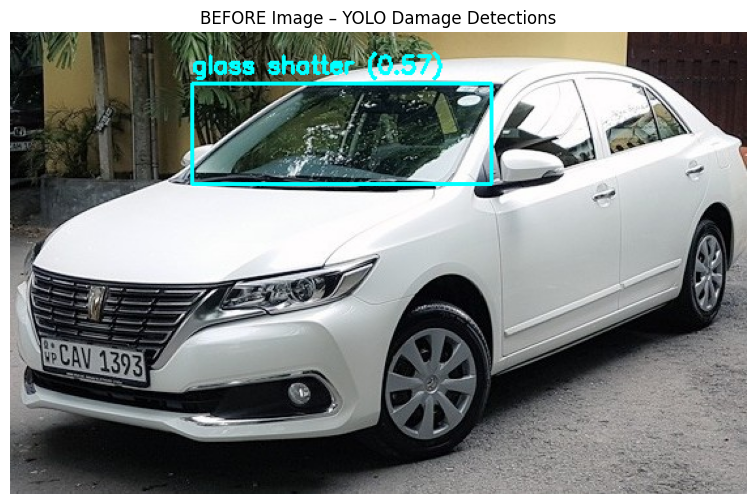

In [27]:
# Load DB and retrieve BEFORE record
db = load_db()
vehicle_id = list(db.keys())[0]  # assuming one active vehicle

before_image = db[vehicle_id]["before_image"]
before_damages = db[vehicle_id]["before_damages"]

print(f"Vehicle ID: {vehicle_id}")

print_damage_list(before_damages, header="BEFORE Damage List")

visualize_damages(
    before_image,
    before_damages,
    title="Pre-existing Damages"
)

## 12. Post-delivery Damage Detection


AFTER Damage List
-----------------
1. dent  | confidence = 0.66
2. scratch  | confidence = 0.53
3. lamp broken  | confidence = 0.43
4. scratch  | confidence = 0.41
5. scratch  | confidence = 0.40


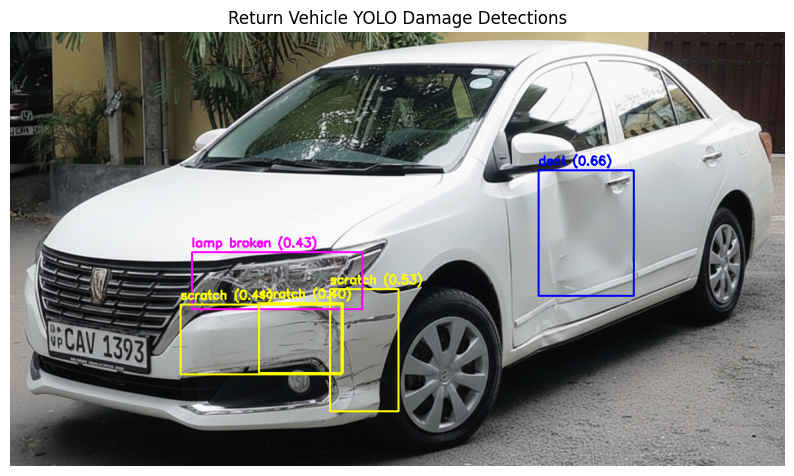

In [28]:
db = load_db()
vehicle_id = list(db.keys())[0]

if "last_after_image" not in db[vehicle_id]:
    print("No AFTER record found.")
    print("Run get_new_damages(after_image_path) successfully first.")
else:
    after_image = db[vehicle_id]["last_after_image"]
    after_damages = db[vehicle_id]["last_after_damages"]

    print_damage_list(after_damages, header="AFTER Damage List")

    visualize_damages(
        after_image,
        after_damages,
        title="Return Vehicle's Damages"
    )

## 13. Identify New Damages


NEW Damages Detected
--------------------
1. dent  | confidence = 0.66
2. scratch  | confidence = 0.53
3. lamp broken  | confidence = 0.43
4. scratch  | confidence = 0.41
5. scratch  | confidence = 0.40


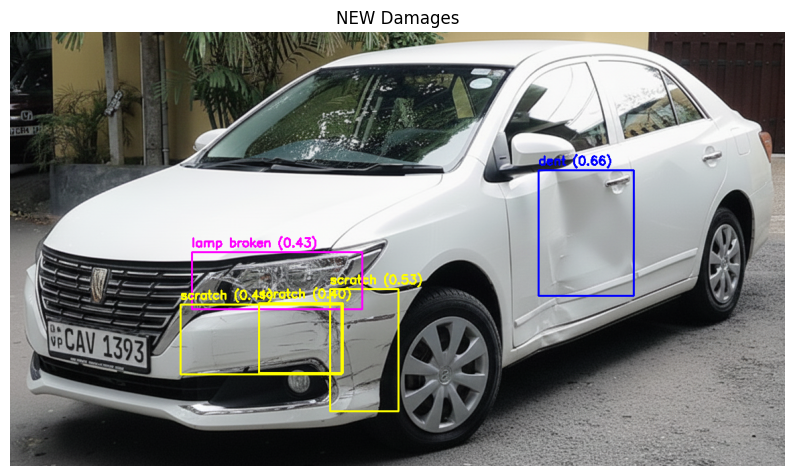

In [29]:
if "new_damages_last_check" not in db[vehicle_id]:
    print("No NEW damage comparison found.")
    print("Run get_new_damages(after_image_path) successfully first.")
else:
    new_damages = db[vehicle_id]["new_damages_last_check"]

    print_damage_list(new_damages, header="New Damages")

    visualize_damages(
        after_image,
        new_damages,
        title="New Damages"
    )